In [ ]:
import pandas as pd
df=pd.read_csv('../train.csv')

In [2]:
df.head()

,image_id,image_path,writer_id,pen_id
0,4,images/00004.png,W27,8
1,5,images/00005.png,W17,1
2,7,images/00007.png,W01,8
3,8,images/00008.png,W17,5
4,9,images/00009.png,W24,4


In [3]:
df.groupby("writer_id")["pen_id"].nunique().value_counts()

pen_id
8    44
7     1
Name: count, dtype: int64

In [4]:
print(df["pen_id"].nunique())
print(df.shape)

8
(40250, 4)


In [5]:
pen_counts = df["pen_id"].value_counts().sort_index()
print(pen_counts)

pen_id
1    5050
2    5000
3    4950
4    5000
5    5100
6    5050
7    5050
8    5050
Name: count, dtype: int64


In [6]:
print((pen_counts / len(df)) * 100)

pen_id
1    12.546584
2    12.422360
3    12.298137
4    12.422360
5    12.670807
6    12.546584
7    12.546584
8    12.546584
Name: count, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["pen_id"],
    random_state=42
)

print(len(train_df), len(val_df))

32200 8050


In [8]:
pen_counts = train_df["pen_id"].value_counts().sort_index()
print(pen_counts)

pen_id
1    4040
2    4000
3    3960
4    4000
5    4080
6    4040
7    4040
8    4040
Name: count, dtype: int64


In [9]:
pen_counts = val_df["pen_id"].value_counts().sort_index()
print(pen_counts)

pen_id
1    1010
2    1000
3     990
4    1000
5    1020
6    1010
7    1010
8    1010
Name: count, dtype: int64


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class PenDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_path = os.path.join(self.root_dir, row["image_path"])
        image = Image.open(img_path).convert("RGB")
        
        label = int(row["pen_id"]) - 1  # convert to 0-based
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [10]:
# read an image and print its shape
from PIL import Image
i1=Image.open('../images/00001.png')
print(i1.size)

(101, 98)


In [11]:
# print no of channels
print(i1.getbands())

('R', 'G', 'B')


In [ ]:
# i want to understand image resolution and channels. so i will print the shape of the image
print(i1.size)
print(i1.getbands())

In [17]:
from PIL import Image
import os
import pandas as pd

widths = []
heights = []

for path in df["image_path"]:  # sample for speed
    img = Image.open(os.path.join("", path))
    w, h = img.size
    widths.append(w)
    heights.append(h)

sizes_df = pd.DataFrame({
    "width": widths,
    "height": heights
})

print(sizes_df.describe())

              width        height
count  40250.000000  40250.000000
mean      96.915876    101.029342
std       30.865565     26.452627
min       15.000000     18.000000
25%       76.000000     82.000000
50%       90.000000     97.000000
75%      110.000000    115.000000
max      370.000000    211.000000


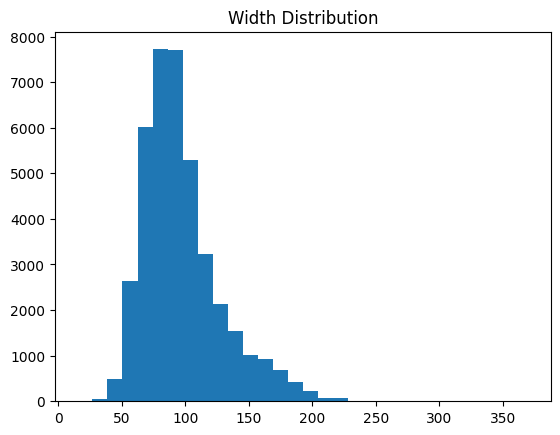

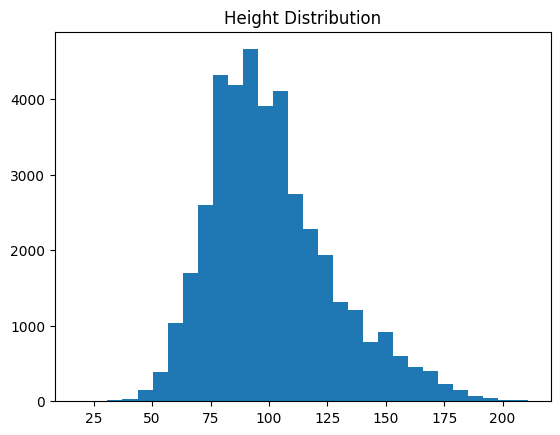

In [18]:
import matplotlib.pyplot as plt

plt.hist(widths, bins=30)
plt.title("Width Distribution")
plt.show()

plt.hist(heights, bins=30)
plt.title("Height Distribution")
plt.show()

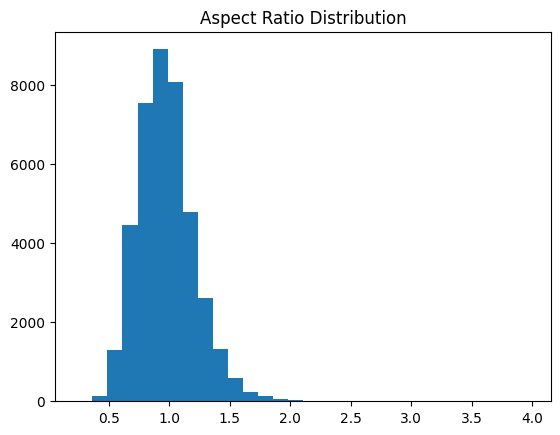

In [19]:
aspect_ratios = [w/h for w, h in zip(widths, heights)]

plt.hist(aspect_ratios, bins=30)
plt.title("Aspect Ratio Distribution")
plt.show()

In [41]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import os
import random

# define transforms
resize = transforms.Resize((128,128))
resize2 = transforms.Resize((256,256))

# pad=transforms.Pad(100) 
# crop = transforms.RandomCrop(128)
# crop = transforms.CenterCrop(256)

def visualize_transforms(df, root_dir, num_images=5):
    sample_rows = df.sample(num_images)

    plt.figure(figsize=(12, 3 * num_images))

    for i, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = os.path.join(root_dir, row["image_path"])
        img = Image.open(img_path).convert("RGB")

        # apply transforms step by step
        img_resized = resize(img)
        img_resized2 = resize2(img)

        # padded_img = pad(img_resized)
        # img_cropped = crop(img_resized)

        # plot original
        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(img)
        plt.title(f"Original\n{img.size}")
        plt.axis("off")

        # plot resized
        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(img_resized)
        plt.title(f"Resized\n{img_resized.size}")
        plt.axis("off")

        # plot cropped
        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(img_resized2)
        plt.title(f"Cropped\n{img_resized2.size}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

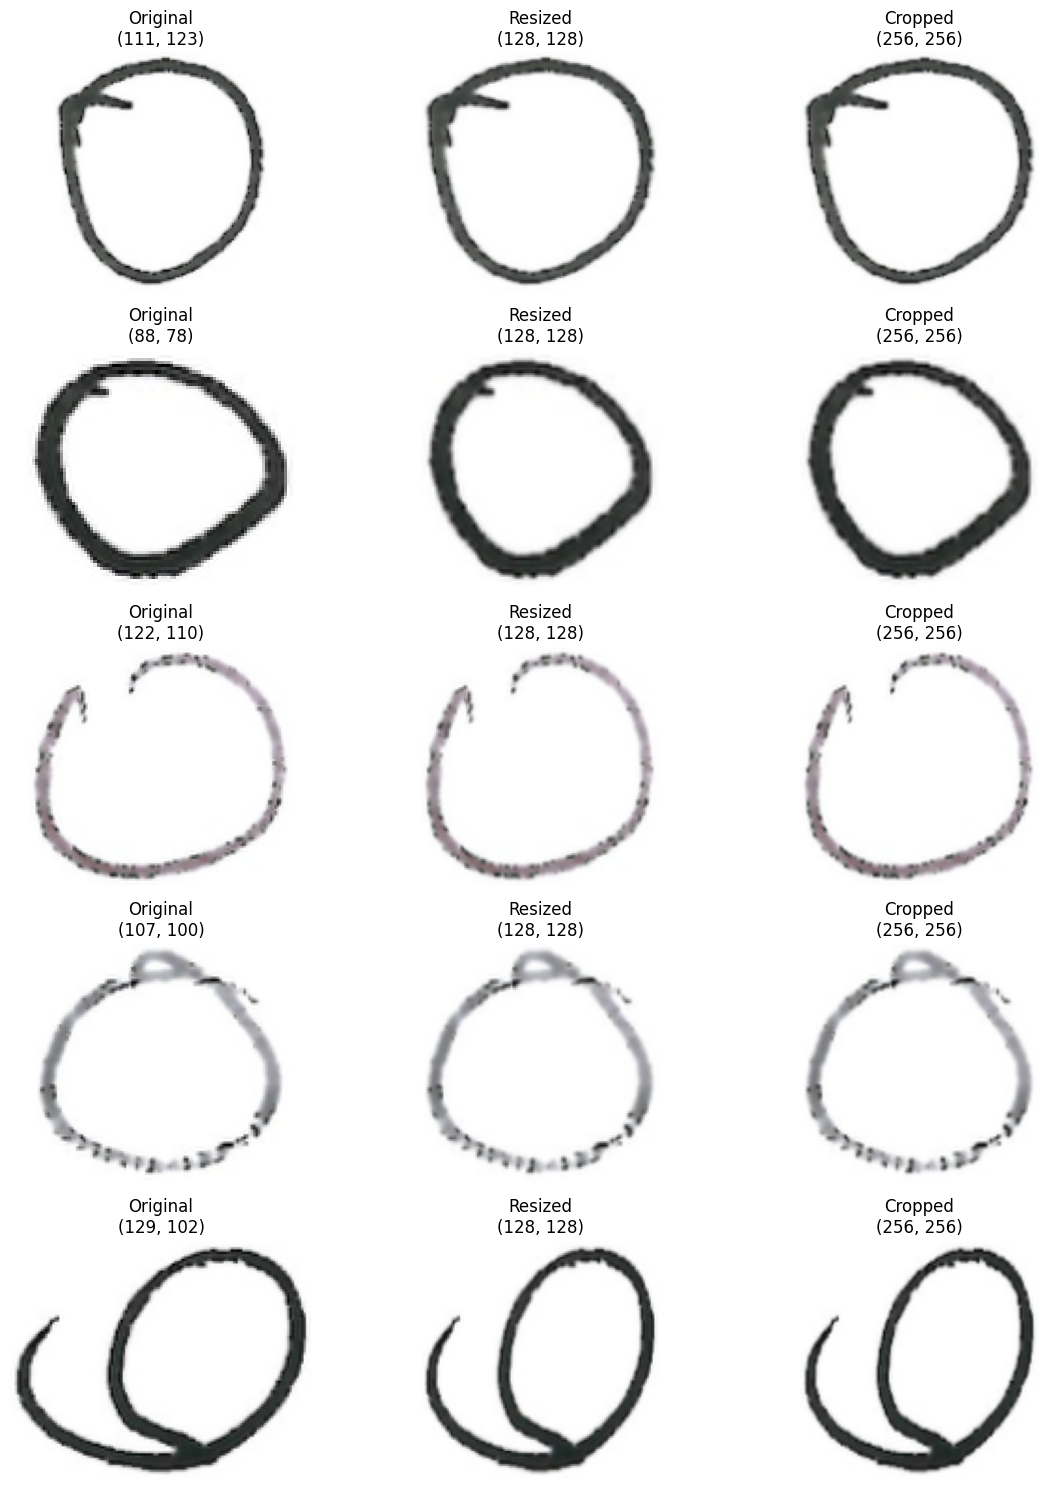

In [43]:
visualize_transforms(df, root_dir="", num_images=5)